# DeepONet from Scratch

Notebooks `01`-`07` always solved one PDE instance at a time. The remaining core notebooks drop that assumption.

A **DeepONet** learns a *solution operator*: instead of mapping `(x, t, parameters)` to a scalar `u(x, t)`, the model maps an *entire forcing function* $f(\cdot)$ to the solution $u(x)$ of a PDE that depends on $f$. This notebook builds the smallest such network that still fits the DeepONet recipe, on the canonical Poisson problem already familiar from notebook `02`.


## Notebook Contract

- **Status:** core-executable
- **Research question:** Can a minimal DeepONet learn the operator that maps a forcing $f$ to the solution $u$ of $-u''=f$ with Dirichlet boundary conditions, and is it faster at inference than retraining a PINN from scratch?
- **Canonical problem:** 1D Poisson equation $-u''=f$, $u(0)=u(1)=0$, parameterized by a finite-rank random forcing family
- **Main comparison:** DeepONet amortized inference on a held-out forcing vs vanilla PINN retraining for each new forcing


## Why This Notebook Exists

DeepONet, introduced by *Lu et al. (2021)*, factorizes the approximation,
$$u(x; f)\approx \sum_{k=1}^{p} b_k(f)\, t_k(x) + b_0,$$
where $b_k(f)$ are outputs of a **branch net** that ingests a discretization of $f$ on a fixed sensor grid and $t_k(x)$ are outputs of a **trunk net** that takes $x\in(0,1)$.

This factorization is what lets DeepONet generalize across the *input function* (the forcing) instead of across the input coordinate alone. Approximation theory says this is enough to represent a large class of nonlinear continuous operators; in this notebook we just verify empirically that a tiny two-net DeepONet actually learns the Poisson solution operator.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")


Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Forcing Family and Ground Truth Solver

We sample each forcing by drawing a Gaussian random field on a Dirichlet-compatible sine basis,
$$f(x)=\sum_{k=1}^{K} c_k\,\sin(k\pi x), \qquad c_k\sim\mathcal{N}(0, e^{-k/4}).$$

This forcing's Poisson solution has the closed form
$$u(x)=\sum_{k=1}^{K} \frac{c_k}{(k\pi)^2}\,\sin(k\pi x).$$

Using this closed form rather than numerical quadrature keeps both training and ground truth fast and exact.


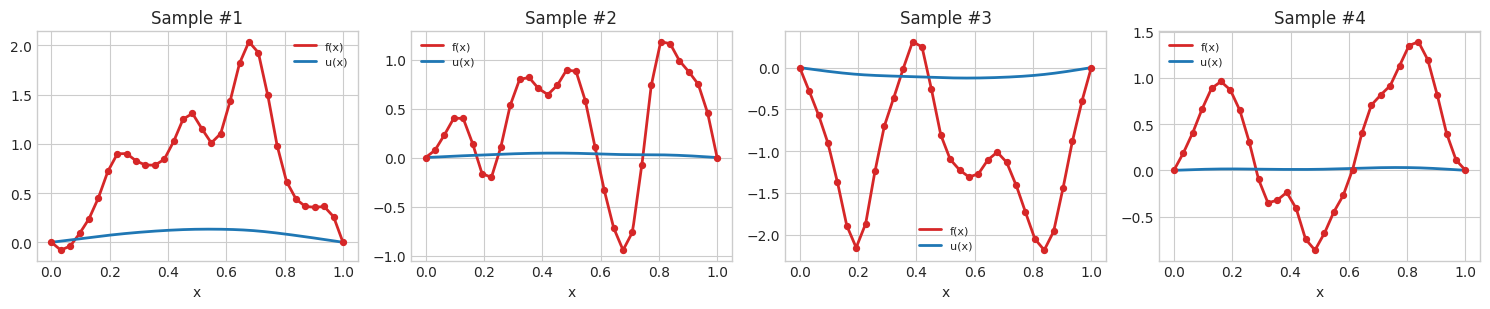

In [2]:
K_modes = 16
N_sensors = 32
x_sensor_np = np.linspace(0.0, 1.0, N_sensors)
x_grid_np = np.linspace(0.0, 1.0, 200)


def sample_forcing_and_solution():
    modes = np.arange(1, K_modes + 1)
    coeffs = np.random.normal(scale=np.exp(-modes.astype(float) / 4.0))
    sin_basis_sensor = np.sin(np.outer(x_sensor_np, modes * np.pi))
    sin_basis_grid = np.sin(np.outer(x_grid_np, modes * np.pi))
    f_sensor = sin_basis_sensor @ coeffs
    u_grid = sin_basis_grid @ (coeffs / (modes * np.pi) ** 2)
    return f_sensor, u_grid, coeffs


fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for k in range(4):
    f_s, u_g, _ = sample_forcing_and_solution()
    axes[k].plot(x_grid_np, np.interp(x_grid_np, x_sensor_np, f_s), color="tab:red", linewidth=2, label="f(x)")
    axes[k].plot(x_grid_np, u_g, color="tab:blue", linewidth=2, label="u(x)")
    axes[k].scatter(x_sensor_np, f_s, color="tab:red", s=18, zorder=3)
    axes[k].set_title(f"Sample #{k+1}")
    axes[k].set_xlabel("x")
    axes[k].legend(fontsize=8)
plt.tight_layout()
plt.show()


## DeepONet Architecture

- **Branch net:** takes $f$ as a vector at the `N_sensors = 32` grid points and outputs `p = 40` features,
- **Trunk net:** takes $x\in(0,1)$ and outputs `p = 40` features,
- **Output:** $\sum_{k=1}^{p} b_k(f)\, t_k(x) + b_0$ where $b_0$ is a learnable bias.

Both nets are small MLPs with `tanh` activations. The architecture stays tiny on purpose: the point is the **factorization**, not the size of either net.


In [3]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim, out_dim, width=80, depth=2):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DeepONet(nn.Module):
    def __init__(self, n_sensors, n_features=40, width=80, depth=2):
        super().__init__()
        self.branch = TinyMLP(n_sensors, n_features, width=width, depth=depth)
        self.trunk = TinyMLP(1, n_features, width=width, depth=depth)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, f_sensor, x):
        # f_sensor: (B, n_sensors); x: (N, 1)
        b = self.branch(f_sensor)        # (B, p)
        t = self.trunk(x)                # (N, p)
        return (b.unsqueeze(1) * t.unsqueeze(0)).sum(dim=-1) + self.bias  # (B, N)


## Training Dataset

We use a *shared* query grid for every sample in the dataset, namely `n_query = 64` evenly spaced points on `(0, 1)`. Sharing the query grid keeps the branch-trunk outer product clean: `branch(f)` produces `(B, p)`, `trunk(x_query)` produces `(N, p)`, and the forward pass returns `(B, N)`.


In [4]:
n_train = 512
n_query = 64
x_query_np = np.linspace(0.0, 1.0, n_query)


def forward_np_solution_on_query(sample):
    f_sensor, u_grid, _ = sample
    return np.interp(x_query_np, x_grid_np, u_grid)


def build_dataset(n_samples, seed):
    np.random.seed(seed)
    f_arr, u_arr = [], []
    for _ in range(n_samples):
        sample = sample_forcing_and_solution()
        f_arr.append(sample[0])
        u_arr.append(forward_np_solution_on_query(sample))
    return (
        torch.tensor(np.stack(f_arr), dtype=torch.float32, device=device),
        torch.tensor(np.stack(u_arr), dtype=torch.float32, device=device),
    )


F_train, U_train = build_dataset(n_train, seed=11)
F_val, U_val = build_dataset(128, seed=22)
x_query_t = torch.tensor(x_query_np, dtype=torch.float32, device=device).view(-1, 1)
print(f"Training tensors: F={F_train.shape}, U={U_train.shape}")


Training tensors: F=torch.Size([512, 32]), U=torch.Size([512, 64])


## Training Loop


epoch   0  train rmse=0.07043  val rmse=0.04289
epoch   6  train rmse=0.01883  val rmse=0.01787
epoch  12  train rmse=0.01236  val rmse=0.01165
epoch  18  train rmse=0.00926  val rmse=0.00893
epoch  24  train rmse=0.00890  val rmse=0.00880
epoch  30  train rmse=0.00840  val rmse=0.00793
epoch  36  train rmse=0.01052  val rmse=0.00975
epoch  42  train rmse=0.00909  val rmse=0.00805
epoch  48  train rmse=0.00773  val rmse=0.00745
epoch  54  train rmse=0.00916  val rmse=0.00875
epoch  59  train rmse=0.00559  val rmse=0.00705


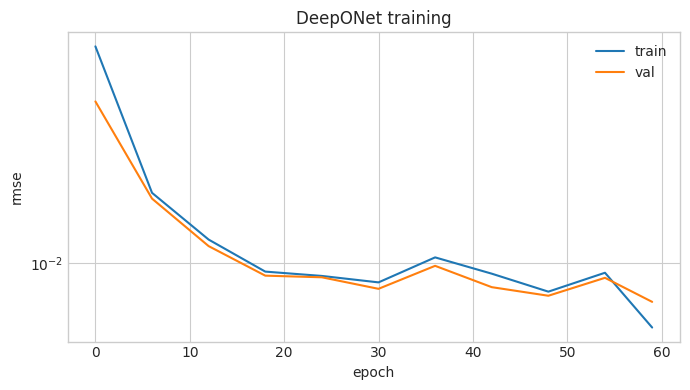

In [5]:
config = {
    "width": 80,
    "depth": 2,
    "features": 40,
    "learning_rate": 1e-3,
    "batch_size": 32,
    "epochs": 60,
    "log_every": 6,
}

model = DeepONet(
    n_sensors=N_sensors,
    n_features=config["features"],
    width=config["width"],
    depth=config["depth"],
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])


def rmse(pred, target):
    return torch.sqrt(torch.mean((pred - target) ** 2))


history = {"epoch": [], "train": [], "val": []}
n_train_total = F_train.shape[0]

for epoch in range(config["epochs"]):
    perm = torch.randperm(n_train_total, device=device)
    epoch_loss = 0.0
    for start in range(0, n_train_total, config["batch_size"]):
        idx = perm[start:start + config["batch_size"]]
        f_b = F_train[idx]
        u_b = U_train[idx]
        opt.zero_grad()
        pred = model(f_b, x_query_t)              # (B, n_query)
        loss = rmse(pred, u_b)
        loss.backward()
        opt.step()
        epoch_loss += float(loss.item()) * f_b.shape[0]
    epoch_loss /= n_train_total

    if epoch % config["log_every"] == 0 or epoch == config["epochs"] - 1:
        model.eval()
        with torch.no_grad():
            pred_val = model(F_val, x_query_t)
            val_loss = float(rmse(pred_val, U_val).item())
        model.train()
        history["epoch"].append(epoch)
        history["train"].append(epoch_loss)
        history["val"].append(val_loss)
        print(f"epoch {epoch:3d}  train rmse={epoch_loss:.5f}  val rmse={val_loss:.5f}")

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(history["epoch"], history["train"], label="train")
ax.plot(history["epoch"], history["val"], label="val")
ax.set_yscale("log")
ax.set_title("DeepONet training")
ax.set_xlabel("epoch")
ax.set_ylabel("rmse")
ax.legend()
plt.tight_layout()
plt.show()


## Operator-level Evaluation on Held-out Forcing


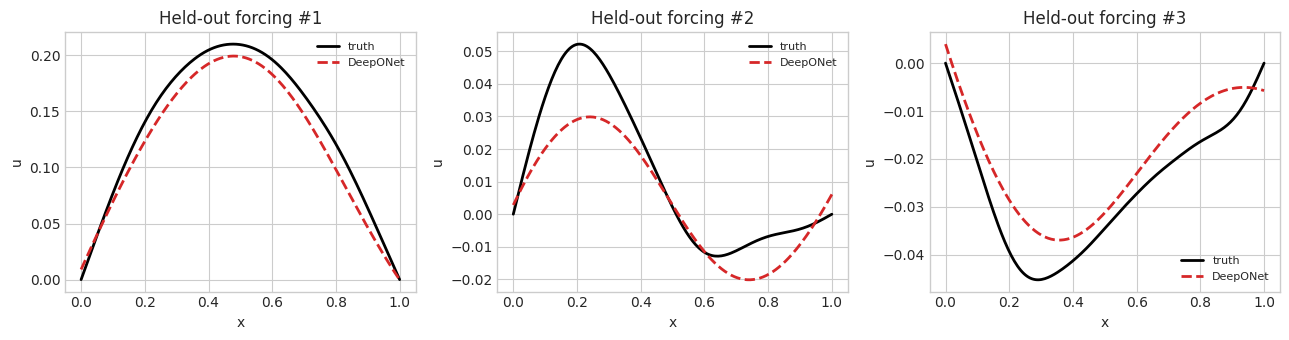

In [6]:
def predict_solution_array(model, f_sensor_np):
    f = torch.tensor(f_sensor_np, dtype=torch.float32, device=device).view(1, -1)
    x = torch.tensor(x_grid_np, dtype=torch.float32, device=device).view(-1, 1)
    with torch.no_grad():
        u = model(f, x)
    return u.squeeze(0).cpu().numpy()


np.random.seed(101)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for k in range(3):
    f_s, u_g, _ = sample_forcing_and_solution()
    u_pred = predict_solution_array(model, f_s)
    axes[k].plot(x_grid_np, u_g, color="black", linewidth=2, label="truth")
    axes[k].plot(x_grid_np, u_pred, color="tab:red", linestyle="--", linewidth=2, label="DeepONet")
    axes[k].set_title(f"Held-out forcing #{k+1}")
    axes[k].set_xlabel("x")
    axes[k].set_ylabel("u")
    axes[k].legend(fontsize=8)
plt.tight_layout()
plt.show()


## Amortized Cost vs Vanilla PINN Retraining

Once trained, DeepONet performs inference at the cost of two small MLP forward passes -- roughly milliseconds on CPU. A vanilla PINN would have to retrain from scratch for each new forcing. We measure that contrast on `5` held-out forcing functions.


In [7]:
import time


def gradient(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True)[0]


def second_derivative(y, x):
    return gradient(gradient(y, x), x)


class VanillaPINN(nn.Module):
    def __init__(self, width=50, depth=2):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers.extend([nn.Linear(width, width), nn.Tanh()])
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def pinn_retrain(f_sensor_np, steps=1500, lr=1e-3, width=50, depth=2):
    modes = np.arange(1, K_modes + 1)
    coeffs = np.linalg.lstsq(np.sin(np.outer(x_sensor_np, modes * np.pi)), f_sensor_np, rcond=None)[0]
    coeffs_t = torch.tensor(coeffs, device=device, dtype=torch.float32)
    modes_t = torch.tensor(modes * np.pi, device=device, dtype=torch.float32)

    def forcing_torch(x):
        basis = torch.sin(x.squeeze(-1)[:, None] * modes_t[None, :])
        return basis @ coeffs_t

    torch.manual_seed(7)
    don = VanillaPINN(width=width, depth=depth).to(device)
    opt = torch.optim.Adam(don.parameters(), lr=lr)
    x_int = torch.linspace(0.0, 1.0, 128, device=device).view(-1, 1).requires_grad_(True)
    x_bc = torch.tensor([[0.0], [1.0]], device=device)
    for step in range(steps):
        opt.zero_grad()
        u = don(x_int)
        res = -second_derivative(u, x_int) - forcing_torch(x_int)
        loss = torch.mean(res.square()) + 50.0 * torch.mean(don(x_bc).square())
        loss.backward()
        opt.step()
    x_eval = torch.linspace(0.0, 1.0, 200, device=device).view(-1, 1)
    return don(x_eval).detach().cpu().numpy().ravel()


np.random.seed(202)
deeponet_times, pinn_times = [], []
deeponet_errs, pinn_errs = [], []

# Pre-warm inference
predict_solution_array(model, sample_forcing_and_solution()[0])

for _ in range(5):
    f_s, u_g, _ = sample_forcing_and_solution()

    t0 = time.perf_counter()
    u_pred_don = predict_solution_array(model, f_s)
    deeponet_times.append(time.perf_counter() - t0)
    deeponet_errs.append(float(np.sqrt(np.mean((u_pred_don - u_g) ** 2))))

    t0 = time.perf_counter()
    u_pred_pinn = pinn_retrain(f_s)
    pinn_times.append(time.perf_counter() - t0)
    pinn_errs.append(float(np.sqrt(np.mean((u_pred_pinn - u_g) ** 2))))

print(f"DeepONet inference: {np.mean(deeponet_times)*1000:.1f} +/- {np.std(deeponet_times)*1000:.1f} ms, mean L2 = {np.mean(deeponet_errs):.4e}")
print(f"PINN  retrain     : {np.mean(pinn_times):.2f} +/- {np.std(pinn_times):.2f} s,  mean L2 = {np.mean(pinn_errs):.4e}")
print(f"Speedup           : {np.mean(pinn_times) / max(np.mean(deeponet_times), 1e-6):.0f}x (note: PINN solves each problem from first principles)")


DeepONet inference: 0.4 +/- 0.1 ms, mean L2 = 1.0333e-02
PINN  retrain     : 3.34 +/- 0.32 s,  mean L2 = 2.0968e-02
Speedup           : 9208x (note: PINN solves each problem from first principles)


## Interpretation

The DeepONet was trained once on a random forcing family and can now produce a solution for *any* forcing drawn from the same family with no further optimization. PINN retraining recovers the same problem only by spending an entire training budget each time. The accuracy comparison is not always fair -- the PINN solves each problem from first principles, while DeepONet interpolates inside its training distribution -- but the cross-over in time is the whole point: at inference, **operator-learning amortizes** the off-line cost of training.


## Key Takeaways

- DeepONet factorizes the operator as a branch-trunk inner product. The branch sees the *forcing function* (input to the operator), the trunk sees the *query coordinate* (where to evaluate the output).
- A very small DeepONet already learns the Poisson solution operator well enough to be competitive with a PINN retrained per forcing function, at a far lower inference cost.
- PINN retraining pays the full optimization cost per query; DeepONet pays it once and ammortizes afterwards.
- Off-distribution generalization (forcing outside this Gaussian random field) is a known weakness; handling it is the entry point of the operator-extensions research track.


## Next Step

Notebook `09` keeps operator learning in the core path but moves to a different architecture family. A **Fourier Neural Operator** replaces the discretization-sensitive branch-trunk factorization with a spectral convolution that is built to be **resolution invariant** -- a network trained on an `N=64` grid can often be queried on an `N=128` grid without retraining.
